## training model on satellite imagery first pass
#### Justin Guthrie | 04/06/2026
Using Ed's code here as a baseline: https://colab.research.google.com/github/edwardoughton/satellite-image-analysis/blob/main/07_01_ggs416_26_03_16.ipynb#scrollTo=a6b06e25

### imports

In [ ]:
# packages for basic Python work
import os                                   # helps with file management
import numpy as np                          # helps work with image arrays
import pandas as pd                         # organize detecions in tables

# packages for display and plotting
import matplotlib.pyplot as plt             # displays images and charts
import matplotlib.patches as patches        # draws rectanges around detected objects
from IPython.display import display         # helps us show tables nicely in a notebook


# packages for satellite imagery
from pystac_client import Client            # searches the Planetary Computer STAC API for satellite imagery
import planetary_computer as pc             # signs the image links so we can access them
import rasterio                             # reads raster imagery such as NAIP
from rasterio.windows import from_bounds    # helps us clip the exact geographic area we need
from rasterio.warp import transform_bounds  # helps us clip the exact geographic area we need



# package for object detection
from ultralytics import YOLO                # the YOLO object detection model

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\guthrie.j\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### helper functions to display an RGB image clearly

In [3]:
# satellite imagery often contains large data values. before plotting, we usually stretch the image so it looks better on screen.

# simple percentile stretch
def stretch_rgb(rgb_bands):
    """Convert a 3-band image from bands-first to bands-last and stretch it for display."""
    rgb_hwc = np.moveaxis(rgb_bands, 0, -1).astype("float32")
    p2 = np.nanpercentile(rgb_hwc, 2)
    p98 = np.nanpercentile(rgb_hwc, 98)
    return np.clip((rgb_hwc - p2) / (p98 - p2 + 1e-6), 0, 1)

# displays an image with a tile
def show_image(img, title, figsize=(7, 7)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

### helper functions to search for a NAIP image

In [4]:
# search the Planetary Computer for NAIP imagery. it does three things:
#   1. searches for NAIP scenes that intersect our bounding box
#   2. keeps the most recent date
#   3. chooses the scene with the greatest overlap with our area of interest

def bbox_overlap_area(a, b):
    """Calculate the overlap area of two lon/lat bounding boxes."""
    minx = max(a[0], b[0])
    miny = max(a[1], b[1])
    maxx = min(a[2], b[2])
    maxy = min(a[3], b[3])
    if maxx <= minx or maxy <= miny:
        return 0.0
    return (maxx - minx) * (maxy - miny)


def get_latest_naip_item(bbox, datetime="2021-01-01/2024-12-31"):
    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace,
    )

    items = list(
        catalog.search(
            collections=["naip"],
            bbox=bbox,
            datetime=datetime,
            limit=12,
            method="POST",
        ).items()
    )

    if not items:
        raise ValueError("No NAIP scenes found for the requested bbox and date range.")

    latest_date = max(item.datetime for item in items if item.datetime).date()
    same_day_items = [item for item in items if item.datetime and item.datetime.date() == latest_date]
    return max(same_day_items, key=lambda item: bbox_overlap_area(bbox, item.bbox))

### helper functions to clip the image to our study area

In [5]:
# the NAIP image is stored in a projected coordinate system, but out bounding box is written in lat/long. so, we have to:
#   1. convert the lat/long bounding box into the raster's coordinate system
#   2. build a raster window from those bounds
#   3. read only the 3 RGB bands we need

def read_naip_clip(item, bbox):
    href = item.assets["image"].href

    with rasterio.open(href) as src:
        minx, miny, maxx, maxy = transform_bounds("EPSG:4326", src.crs, *bbox)
        window = from_bounds(minx, miny, maxx, maxy, src.transform)
        rgb = src.read([1, 2, 3], window=window)

    if rgb.shape[1] == 0 or rgb.shape[2] == 0:
        raise ValueError("The requested bbox produced an empty image. Try a different location.")

    return rgb

### choose a place to analyze

In [22]:
# starting with a tight airport area because large parked airplanes are relatively easy for a generic pretrained YOLO model to detect from overhead imagery

site_name = "Dulles Airport"
bbox = (-77.4555, 38.944, -77.448, 38.950)

### find the image and inspect its metadata

In [23]:
# searches the catalog and prints the date of the image we selected

item = get_latest_naip_item(bbox)
print("Selected site:", site_name)
print("Selected NAIP acquisition date:", item.datetime.date())
print(item.id)

Selected site: Dulles Airport
Selected NAIP acquisition date: 2023-10-11
va_m_3807705_nw_18_060_20231011_20240103


### read and display the clipped image

Raw raster shape: (3, 1139, 1113)
Display image shape: (1139, 1113, 3)


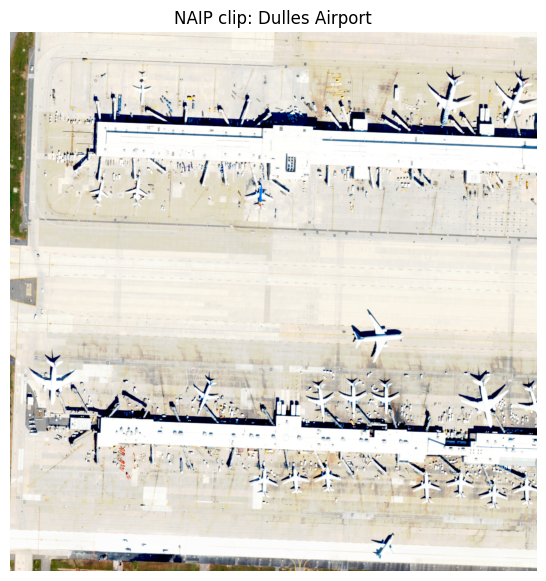

In [24]:
# read the image into memory, stretch it for display, and show it.
# notice the data shape before and after stretching:
#       - raw raster: (bands, rows, cols)
#       - display image: (rows, cols, bands)

rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)

print("Raw raster shape:", rgb.shape)
print("Display image shape:", rgb_display.shape)
show_image(rgb_display, f"NAIP clip: {site_name}")

### why tile the image?

Large aerial images are usually too large to process at full size with a detector.

We create smaller image tiles because:
- the model expects images near a standard size such as 640 x 640 pixels
- small targets like vehicles and aircraft are easier to detect if we do not shrink the whole scene too much
- tiling makes it easier to scale the workflow to large study areas

### helper functions to create image tiles 

In [26]:
# calculates where each tile should begin
def compute_positions(length, tile_size, overlap):
    step = max(tile_size - overlap, 1)
    if length <= tile_size:
        return [0]

    positions = list(range(0, length - tile_size + 1, step))
    if positions[-1] != length - tile_size:
        positions.append(length - tile_size)
    return positions

# actually cuts the image into tiles
def make_tiles(image_hwc, tile_size=640, overlap=96):
    height, width, _ = image_hwc.shape
    y_positions = compute_positions(height, tile_size, overlap)
    x_positions = compute_positions(width, tile_size, overlap)

    tiles = []
    for y0 in y_positions:
        for x0 in x_positions:
            y1 = min(y0 + tile_size, height)
            x1 = min(x0 + tile_size, width)
            tile = image_hwc[y0:y1, x0:x1]
            tiles.append({"x0": x0, "y0": y0, "x1": x1, "y1": y1, "image": tile})
    return tiles

### display a few example tiles

Number of tiles: 4


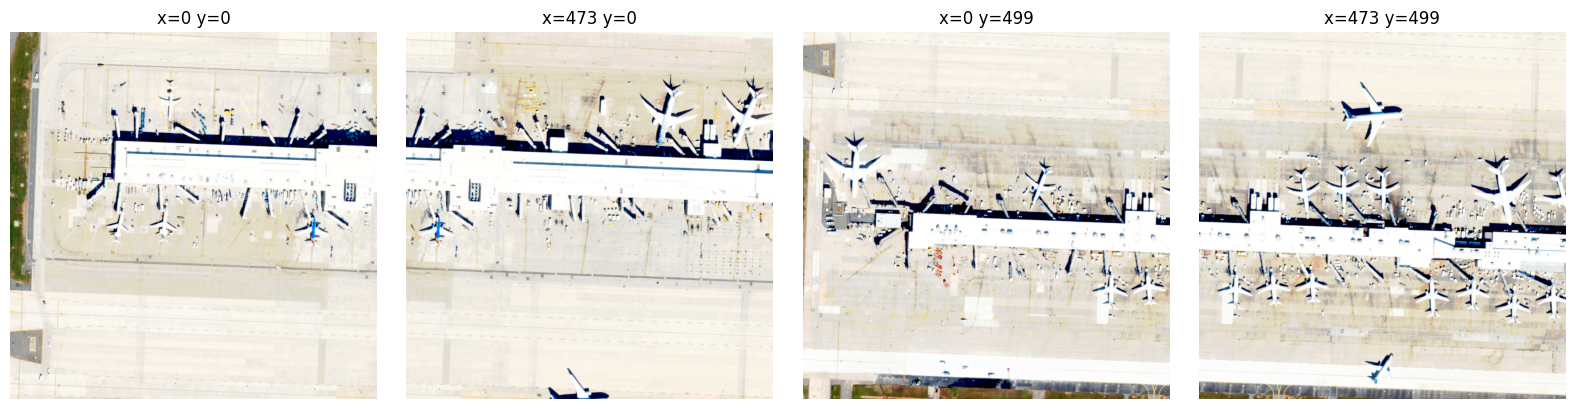

In [27]:
# inspect a few tiles and make sure they look reasonable
def plot_tiles(image_hwc, tiles, max_tiles=4):
    n = min(len(tiles), max_tiles)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, tile in zip(axes, tiles[:n]):
        ax.imshow(tile["image"])
        ax.set_title(f"x={tile['x0']} y={tile['y0']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
print("Number of tiles:", len(tiles))
plot_tiles(rgb_display, tiles, max_tiles=4)

### run YOLO on each tile

The main detection function. It loops through the tiles, runs the pretrained model, and stores the results in a pandas table.
A few details matter:
- YOLO expects image-like values, so we convert each tile from 0-1 floats to 0-255 unsigned integers
- each detection gives us a class, a confidence score, and a bounding box
- we shift each box back into the full-image coordinate system using the tile offsets

In [28]:
def run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640):
    rows = []

    for tile_id, tile in enumerate(tiles):
        tile_img = (tile["image"] * 255).clip(0, 255).astype("uint8")
        result = model.predict(tile_img, conf=conf, imgsz=imgsz, verbose=False)[0]
        boxes = result.boxes

        if boxes is None or len(boxes) == 0:
            continue

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            class_id = int(box.cls[0].cpu().numpy())
            score = float(box.conf[0].cpu().numpy())
            label = model.names[class_id]

            rows.append({
                "tile_id": tile_id,
                "label": label,
                "confidence": score,
                "xmin": x1 + tile["x0"],
                "ymin": y1 + tile["y0"],
                "xmax": x2 + tile["x0"],
                "ymax": y2 + tile["y0"],
            })

    return pd.DataFrame(rows)

### load the pretrained YOLO model (yolov8n.pt)

In [16]:
!wget https://raw.githubusercontent.com/edwardoughton/satellite-image-analysis/main/yolov8n.pt
model = YOLO("yolov8n.pt")

'wget' is not recognized as an internal or external command,
operable program or batch file.


### run detection and inspect the raw table

In [30]:
interesting_labels = {"airplane"}

detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

if detections.empty:
    print("No detections were returned. Try a different site or lower the confidence threshold.")
else:
    detections = detections[detections["label"].isin(interesting_labels)].copy()
    print("Relevant detections:", len(detections))
    display(detections.sort_values("confidence", ascending=False).head(15))

Relevant detections: 16


,tile_id,label,confidence,xmin,ymin,xmax,ymax
32,3,airplane,0.673386,761.712280,1058.418701,812.660583,1111.920166
33,3,airplane,0.645845,719.562622,584.165833,833.647705,697.684814
3,1,airplane,0.409873,719.504883,584.780029,828.176147,639.790405
34,3,airplane,0.191379,493.324829,585.438171,1109.135498,879.685425
35,3,airplane,0.189312,945.867432,711.278381,1112.294922,851.044067
36,3,airplane,0.181602,622.797119,731.908020,685.915039,801.354065
37,3,airplane,0.163276,901.944641,893.943054,954.585388,934.387146
4,1,airplane,0.161337,715.804749,583.849182,1086.199829,639.931702
38,3,airplane,0.132753,623.334473,733.789551,685.091553,778.218384
40,3,airplane,0.088299,945.838074,712.758911,1057.465820,843.351929


### plot detections on the image

label
airplane    16
Name: count, dtype: int64


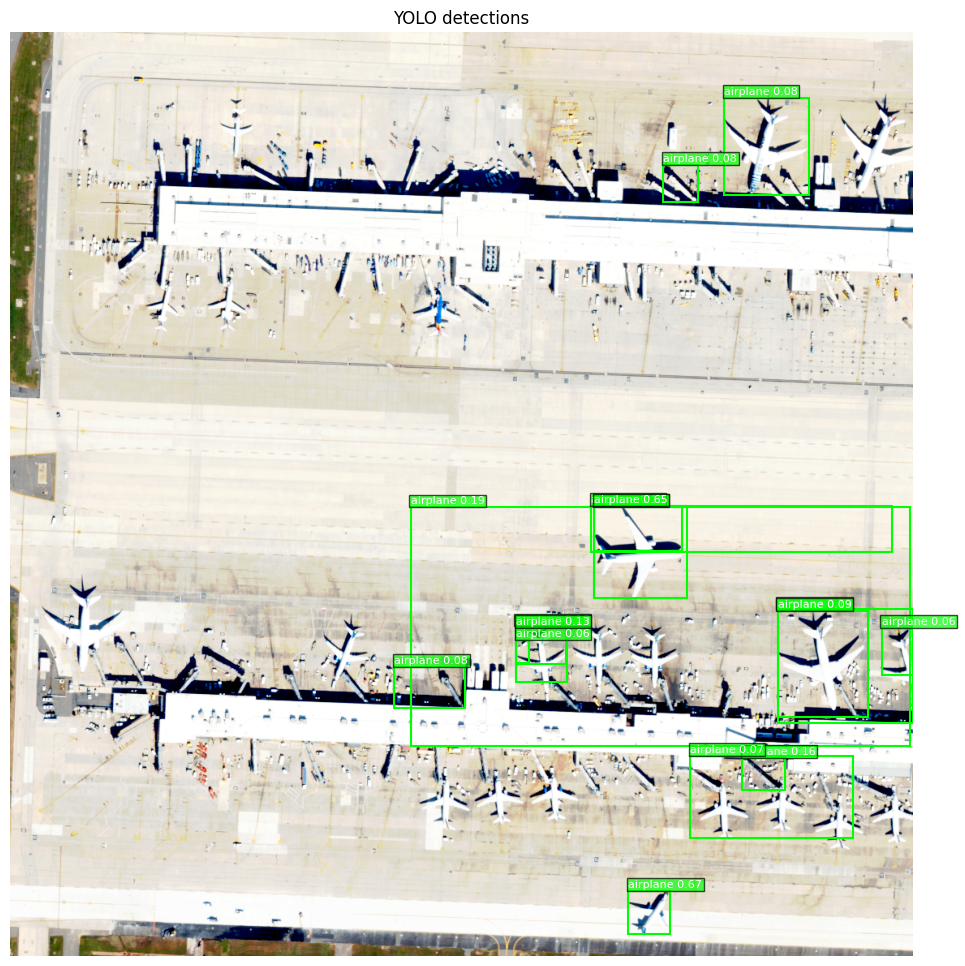

In [31]:
def plot_detections(image_hwc, detections, keep_labels=None, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image_hwc)

    if keep_labels is not None:
        detections = detections[detections["label"].isin(keep_labels)].copy()

    colors = {
        "car": "yellow",
        "truck": "orange",
        "bus": "cyan",
        "boat": "deepskyblue",
        "airplane": "lime",
    }

    for _, row in detections.iterrows():
        width = row["xmax"] - row["xmin"]
        height = row["ymax"] - row["ymin"]
        color = colors.get(row["label"], "red")

        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            width,
            height,
            linewidth=1.5,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            row["xmin"],
            max(0, row["ymin"] - 4),
            f"{row['label']} {row['confidence']:.2f}",
            color="white",
            fontsize=8,
            bbox=dict(facecolor=color, alpha=0.7, pad=1),
        )

    ax.set_title("YOLO detections")
    ax.axis("off")
    plt.show()


if not detections.empty:
    print(detections["label"].value_counts())
    plot_detections(rgb_display, detections, keep_labels=interesting_labels, figsize=(12, 12))

### more sites

Site: Pinal Airpark, AZ
Image date: 2023-09-16
Detections by class:
label
airplane    124
Name: count, dtype: int64


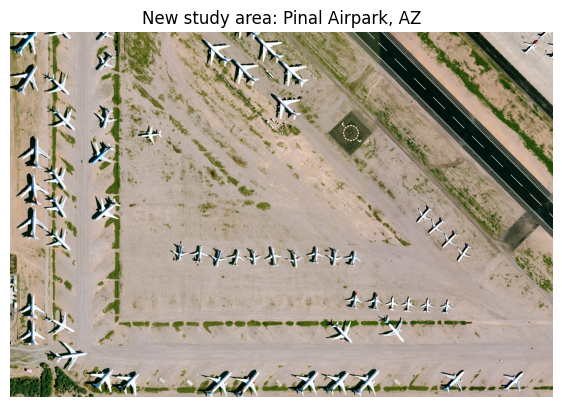

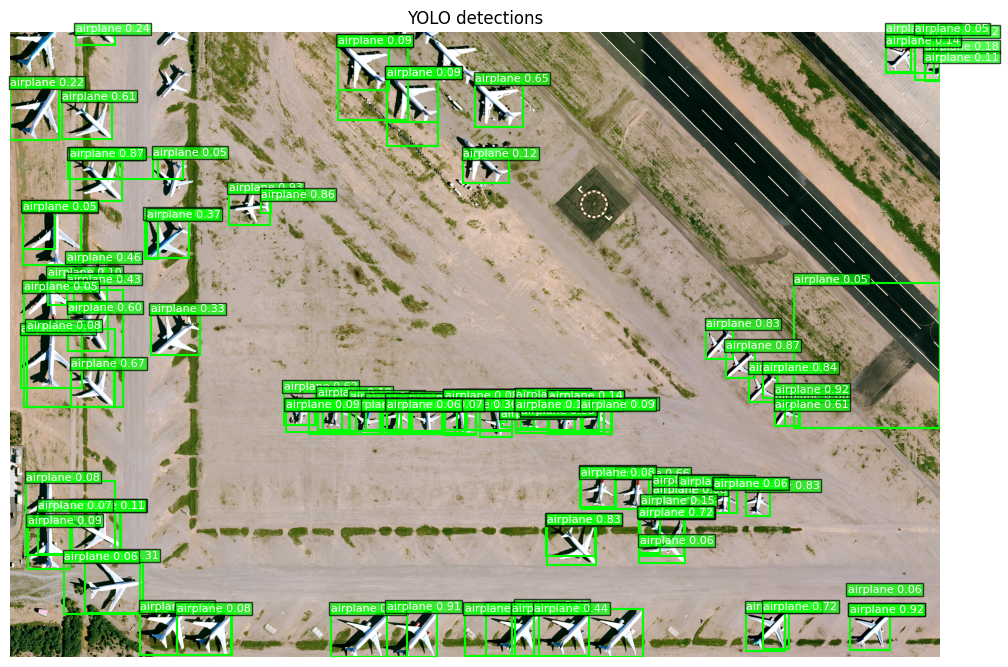

In [32]:
# Example
# Step 1: Pick area of interest
site_name = "Pinal Airpark, AZ"
bbox = (-111.334, 32.5027, -111.321151, 32.51)

# Step 2: rerun the workflow
item = get_latest_naip_item(bbox)
rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)
tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

if detections.empty:
    print("No detections returned for this site. Try another bbox or a lower confidence threshold.")
else:
    detections = detections[detections["label"].isin(interesting_labels)].copy()
    print("Site:", site_name)
    print("Image date:", item.datetime.date())
    print("Detections by class:")
    print(detections["label"].value_counts())
    show_image(rgb_display, f"New study area: {site_name}")
    plot_detections(rgb_display, detections, keep_labels=interesting_labels, figsize=(12, 12))

### trying it out on a substation

### baseline detection across four infrastructure sectors
Running the pretrained YOLO model (trained on COCO) on one representative node per sector.
Goal: document what the model detects — and what it misses — to motivate domain-specific pretraining.
Sectors: Power (substation), Water (wastewater treatment), Telecom (tower yard), Transportation (airport)

#### sector 1: power — Metcalf Energy Center substation, San Jose, CA
Large transmission substation. Visually distinctive: grid of transformers, switching equipment, busbars.

In [ ]:
# Power infrastructure: Metcalf Energy Center substation, San Jose, CA
# Large transmission substation — transformers, switching equipment, busbars visible from overhead
site_name = "Metcalf Substation, San Jose, CA"
bbox = (-121.750, 37.215, -121.740, 37.225)  # ~1km window centered on substation

item = get_latest_naip_item(bbox)
rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)
tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

# note: COCO-trained YOLO has no substation class
# logging all detections regardless of label to see what it does pick up
interesting_labels_power = set(model.names.values())  # all classes

if detections.empty:
    print(f"[{site_name}] No detections returned. YOLO does not recognize this asset type.")
    print("This is expected — COCO has no overhead infrastructure classes.")
else:
    print(f"Site: {site_name}")
    print(f"Image date: {item.datetime.date()}")
    print("All detections by class:")
    print(detections["label"].value_counts())
    show_image(rgb_display, f"{site_name}")
    plot_detections(rgb_display, detections, figsize=(12, 12))


#### sector 2: water — Deer Island Wastewater Treatment Plant, Boston, MA
One of the largest wastewater treatment facilities in the US. Circular digesters are visually unmistakable from overhead.

In [ ]:
# Water infrastructure: Deer Island Wastewater Treatment Plant, Boston, MA
# Distinctive circular digester domes — one of the most visually identifiable water assets from overhead
site_name = "Deer Island Wastewater Treatment Plant, Boston, MA"
bbox = (-70.960, 42.342, -70.950, 42.352)  # ~1km window centered on plant

item = get_latest_naip_item(bbox)
rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)
tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

if detections.empty:
    print(f"[{site_name}] No detections returned. YOLO does not recognize this asset type.")
    print("This is expected — COCO has no water infrastructure classes.")
else:
    print(f"Site: {site_name}")
    print(f"Image date: {item.datetime.date()}")
    print("All detections by class:")
    print(detections["label"].value_counts())
    show_image(rgb_display, f"{site_name}")
    plot_detections(rgb_display, detections, figsize=(12, 12))


#### sector 3: telecom — North Yarmouth Telecom Yard, North Yarmouth, ME
Rural/suburban telecom infrastructure node: cell tower + supporting equipment buildings. Representative of real-world telecom inventory.

In [ ]:
# Telecom infrastructure: North Yarmouth Telecom Yard, North Yarmouth, ME
# Cell tower + equipment buildings — representative rural/suburban telecom node
site_name = "North Yarmouth Telecom Yard, ME"
bbox = (-70.255, 43.830, -70.245, 43.840)  # ~1km window centered on tower yard

item = get_latest_naip_item(bbox)
rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)
tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

if detections.empty:
    print(f"[{site_name}] No detections returned. YOLO does not recognize this asset type.")
    print("This is expected — COCO has no telecom infrastructure classes.")
else:
    print(f"Site: {site_name}")
    print(f"Image date: {item.datetime.date()}")
    print("All detections by class:")
    print(detections["label"].value_counts())
    show_image(rgb_display, f"{site_name}")
    plot_detections(rgb_display, detections, figsize=(12, 12))


#### sector 4: transportation — O'Hare International Airport, Chicago, IL
Large airport node: runways, terminals, gates. Unambiguous infrastructure boundary. xView includes aircraft classes so partial detections are possible here.

In [ ]:
# Transportation infrastructure: O'Hare International Airport, Chicago, IL
# Airport chosen as transportation node — discrete boundary, visually unambiguous, resilience-relevant
# Note: COCO includes "airplane" class so partial detections are plausible here, unlike other sectors
site_name = "O'Hare International Airport, Chicago, IL"
bbox = (-87.915, 41.975, -87.905, 41.985)  # ~1km window, terminal area

item = get_latest_naip_item(bbox)
rgb = read_naip_clip(item, bbox)
rgb_display = stretch_rgb(rgb)
tiles = make_tiles(rgb_display, tile_size=640, overlap=96)
detections = run_yolo_on_tiles(model, tiles, conf=0.05, imgsz=640)

# airplane is a COCO class -- worth filtering for it specifically here
interesting_labels_transport = {"airplane"}

if detections.empty:
    print(f"[{site_name}] No detections returned.")
else:
    print(f"Site: {site_name}")
    print(f"Image date: {item.datetime.date()}")
    print("All detections by class:")
    print(detections["label"].value_counts())
    show_image(rgb_display, f"{site_name}")
    plot_detections(rgb_display, detections, keep_labels=interesting_labels_transport, figsize=(12, 12))


#### baseline summary
Expected pattern across sectors:
- **Power, Water, Telecom**: few or no detections — COCO has no overhead infrastructure classes for these
- **Transportation (airport)**: possible airplane detections since COCO includes that class

This failure pattern is the empirical motivation for domain-specific pretraining.
A model pretrained on a curated infrastructure corpus should detect these assets where COCO-trained YOLO cannot.